EDA 


In [4]:
import pandas as pd
netflix = pd.read_csv("netflix_titles.csv")

print(netflix.head())
print(netflix.shape)
print(netflix.info())

print(netflix.columns)

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [5]:
#MISSING VALUES
print(netflix.isnull().sum())            #number of missing (empty) values in every column.
print(f"Columns with missing values:\n{netflix.isnull().sum()[netflix.isnull().sum() > 0]}")        #columns that have missing values

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64
Columns with missing values:
director      2634
cast           825
country        831
date_added      10
rating           4
duration         3
dtype: int64


In [6]:
#DATA CLEANING
print(f"Duplicate rows: {netflix.duplicated().sum()}")           #number of duplicate rows in the dataset.
netflix = netflix.drop_duplicates()         #remove duplicate rows


Duplicate rows: 0


In [7]:
#TOTAL
print(f"Total shows: { (netflix['type'] == 'TV Show').sum() }")
print(f"total movies:{ (netflix['type'] == 'Movie').sum() }")


Total shows: 2676
total movies:6131


In [8]:
#MOST NETFLIX SHOWS
country = netflix["country"].value_counts()                    #count the number of shows per country
print(f"Country with most shows:\n{country.head(10)}")

Country with most shows:
country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


In [9]:
#MOST APPEARED RATING
rating = netflix["rating"].value_counts()                       #count the number of appearances per rating
print(f"Rating with most appearances:\n{rating.head(10)}")


Rating with most appearances:
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64


In [10]:
#RELEASE YEAR 
year = netflix["release_year"].value_counts()
print(f"Year with most releases:\n{year.head(10)}")

print(f"Earliest release year: {netflix['release_year'].min()}")
print(f"Latest release year: {netflix['release_year'].max()}")

Year with most releases:
release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64
Earliest release year: 1925
Latest release year: 2021


In [11]:
#YEAR WITH HIGHEST NUMBER OF TITLES 
year = netflix["release_year"].value_counts()
print(f"Year with highest number of titles: {year.idxmax()}")
print(f"Number of titles in that year: {year.max()}")


Year with highest number of titles: 2018
Number of titles in that year: 1147


In [12]:
#DIRECTORS WITH MOST TITLES
director = netflix["director"].value_counts()
print(f"Directors with most titles:\n{director.head(10)}")

Directors with most titles:
director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Youssef Chahine           12
Martin Scorsese           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64


In [13]:
#WHICH MONTH WERE THE MOST TITLES ADDED TOO
netflix["month_added"] = netflix["date_added"].str.split().str[0] # Extract the month from the date_added column #.str.split() splits the string into a list of words, and str[0] selects the first word (the month) from that list. This creates a new column called "month_added" in the netflix DataFrame that contains the month when each title was added to Netflix.
month = netflix["month_added"].value_counts()
print(f"Month with most titles added:\n{month.head(10)}")


Month with most titles added:
month_added
July         827
December     813
September    770
April        764
October      760
August       755
March        742
January      738
June         728
November     705
Name: count, dtype: int64


In [14]:
#WHICH YEAR WAS CONTAINED THE MOST TITLES ADDED
netflix["date_added"] = pd.to_datetime(netflix["date_added"].str.strip(), errors="coerce")
netflix["year_added"] = netflix["date_added"].dt.year           # Extract the year from the date_added column
year_added = netflix["year_added"].value_counts()                 #count the number of titles added per year
print(f"Year with most titles added:\n{year_added.head(10)}")


Year with most titles added:
year_added
2019.0    2016
2020.0    1879
2018.0    1649
2021.0    1498
2017.0    1188
2016.0     429
2015.0      82
2014.0      24
2011.0      13
2013.0      11
Name: count, dtype: int64


In [15]:
#MOVIES RELEASED AFTER 2018
netflix[
    (netflix["type"] == "Movie") &            #condition to filter the DataFrame for movies released after 2018
    (netflix["release_year"] > 2018)
]

#TV SHOWS RELEASED AFTER 2020
netflix[
    (netflix["type"] == "TV Show") &            
    (netflix["release_year"] > 2020)
]


#ALL MOVIES FROM INDIA                      
india_movies = netflix[                           #using variable to store the filtered DataFrame for movies from India for later use
    (netflix["type"] == "Movie") &
    (netflix["country"] == "India")
]
print(india_movies.head())


#TITLE AND DIRECTOR ONLY                           #.loc 
india_movies = netflix.loc[
    (netflix["type"] == "Movie") &
    (netflix["country"] == "India"),
    ["title", "director"]
]
print(india_movies)                                  #.head() method is used to display the first 5 rows of the DataFrame. 

india_movies = netflix.loc[
    (netflix["type"] == "Movie") &
    (netflix["country"] == "India"),
    ["title", "rating"]
]
print(india_movies)    



#MOVIES AFTER 2018
netflix.loc[
    (netflix["type"] == "Movie") &
    (netflix["release_year"] > 2018),
    ["title", "country", "release_year"]
]


    show_id   type             title              director  \
24      s25  Movie             Jeans            S. Shankar   
105    s106  Movie  Angamaly Diaries  Lijo Jose Pellissery   
114    s115  Movie            Anjaam          Rahul Rawail   
116    s117  Movie            Dhanak       Nagesh Kukunoor   
118    s119  Movie           Gurgaon         Shanker Raman   

                                                  cast country date_added  \
24   Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...   India 2021-09-21   
105  Antony Varghese, Reshma Rajan, Binny Rinky Ben...   India 2021-09-05   
114  Madhuri Dixit, Shah Rukh Khan, Tinnu Anand, Jo...   India 2021-09-02   
116  Krrish Chhabria, Hetal Gada, Vipin Sharma, Gul...   India 2021-09-02   
118  Akshay Oberoi, Pankaj Tripathi, Ragini Khanna,...   India 2021-09-02   

     release_year rating duration  \
24           1998  TV-14  166 min   
105          2017  TV-14  128 min   
114          1994  TV-14  143 min   
116          201

,title,country,release_year
0,Dick Johnson Is Dead,United States,2020
6,My Little Pony: A New Generation,NaN,2021
9,The Starling,United States,2021
12,Je Suis Karl,"Germany, Czech Republic",2021
13,Confessions of an Invisible Girl,NaN,2021
...,...,...,...
8516,The Spy Who Fell to Earth,United Kingdom,2019
8631,Trixie Mattel: Moving Parts,United States,2019
8718,Westside vs. the World,NaN,2019
8752,Wish Man,United States,2019


In [16]:
#.iloc
netflix.iloc[10]                               #shows the 10th row  
netflix.iloc[10:20]                             #shows rows 10 to 20
netflix.iloc[:, 0]                              #shows all rows of column 0
netflix.iloc[:, 0:5]                            #shows columns 0 to 5
netflix.iloc[50:60, 2:6]                        #shows rows 50 to 60 and columns 2 to 6


,title,director,cast,country
50,Dharmakshetra,NaN,"Kashmira Irani, Chandan Anand, Dinesh Mehta, A...",India
51,InuYasha the Movie 2: The Castle Beyond the Lo...,Toshiya Shinohara,"Kappei Yamaguchi, Satsuki Yukino, Mieko Harada...",Japan
52,InuYasha the Movie 3: Swords of an Honorable R...,Toshiya Shinohara,"Kappei Yamaguchi, Satsuki Yukino, Koji Tsujita...",Japan
53,InuYasha the Movie 4: Fire on the Mystic Island,Toshiya Shinohara,"Kappei Yamaguchi, Satsuki Yukino, Koji Tsujita...",Japan
54,InuYasha the Movie: Affections Touching Across...,Toshiya Shinohara,"Kappei Yamaguchi, Satsuki Yukino, Koji Tsujita...",Japan
55,Nailed It,NaN,"Nicole Byer, Jacques Torres",United States
56,Naruto Shippuden the Movie: Blood Prison,Masahiko Murata,"Junko Takeuchi, Chie Nakamura, Rikiya Koyama, ...",Japan
57,Naruto Shippûden the Movie: Bonds,Hajime Kamegaki,"Junko Takeuchi, Chie Nakamura, Noriaki Sugiyam...",Japan
58,Naruto Shippûden the Movie: The Will of Fire,Masahiko Murata,"Junko Takeuchi, Chie Nakamura, Kazuhiko Inoue,...",Japan
59,Naruto Shippuden: The Movie,Hajime Kamegaki,"Junko Takeuchi, Chie Nakamura, Yoichi Masukawa...",Japan


In [17]:
#SORTED NETFLIX TITLES
newest = netflix.sort_values(by="release_year", ascending=False)
print(newest.head(10))

oldest = netflix.sort_values(by="release_year", ascending=True)
print(oldest.head(10))

movies_alphabetically = netflix.sort_values(by="title", ascending=True)
print(f"Movies sorted alphabetically:\n{movies_alphabetically.head(10)}")

   show_id     type                                            title  \
1       s2  TV Show                                    Blood & Water   
2       s3  TV Show                                        Ganglands   
3       s4  TV Show                            Jailbirds New Orleans   
31     s32  TV Show                               Chicago Party Aunt   
30     s31    Movie                                  Ankahi Kahaniya   
25     s26  TV Show                             Love on the Spectrum   
23     s24    Movie     Go! Go! Cory Carson: Chrissy Takes the Wheel   
20     s21  TV Show  Monsters Inside: The 24 Faces of Billy Milligan   
19     s20  TV Show                                           Jaguar   
18     s19    Movie                                        Intrusion   

                                             director  \
1                                                 NaN   
2                                     Julien Leclercq   
3                                   


     show_id     type                                             title  \
4250   s4251  TV Show                 Pioneers: First Women Filmmakers*   
7790   s7791    Movie                                    Prelude to War   
8205   s8206    Movie                              The Battle of Midway   
8739   s8740    Movie                Why We Fight: The Battle of Russia   
8763   s8764    Movie                   WWII: Report from the Aleutians   
8660   s8661    Movie     Undercover: How to Operate Behind Enemy Lines   
8419   s8420    Movie  The Memphis Belle: A Story of a\nFlying Fortress   
8436   s8437    Movie                                 The Negro Soldier   
8640   s8641    Movie                                  Tunisian Victory   
7219   s7220    Movie                           Know Your Enemy - Japan   

                                               director  \
4250                                                NaN   
7790                                        Frank Capra

In [18]:
#COUNTIES IN DATASET 
print(f"Number of unique countries in the dataset: {netflix['country'].nunique()}")
print(netflix["type"].unique())


#cleaning countries column
netflix["country"] = netflix["country"].fillna("Unknown")
netflix["country"] = netflix["country"].str.strip()
netflix["country"] = netflix["country"].str.lstrip(", ")
netflix["country"] = netflix["country"].replace(r"^\s*$", "Unknown", regex=True)  #removes 
print(netflix["country"].value_counts().head(10))


Number of unique countries in the dataset: 748
<StringArray>
['Movie', 'TV Show']
Length: 2, dtype: str
country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        200
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


In [19]:
#HANDLING MISSING VALUES
netflix_clean = netflix.dropna()                              #Removes all rows that contain at least one missing (NaN) value
print(f"Shape of cleaned DataFrame: {netflix_clean.shape}")   #rows remain after using dropna()

netflix["director"] = netflix["director"].fillna("Unknown")   #Replace missing values with unknown in the director column
netflix["country"] = netflix["country"].fillna("Unknown")
netflix["cast"] = netflix["cast"].fillna("Unknown")

print(netflix[["director", "country", "cast"]].isnull().sum())  #isnull()Checks for missing values, sum() Counts them only in columns mentioned



Shape of cleaned DataFrame: (5696, 14)
director    0
country     0
cast        0
dtype: int64


In [20]:
#STRING OPERATIONS

#all titles containing "Love"
love_movies = netflix[               
    netflix["title"].str.contains("Love", case=False, na=False)   #.contains Looks for the word "Love" ,case=False Ignores uppercase/lowercase ,na=False Ignores missing values instead of giving an error
]
print(love_movies[["title"]])



#text that starts with a word
starts_with_the = netflix[
    netflix["title"].str.startswith("The", na=False)   #.startswith Looks for titles that start with "The" 
]
print(starts_with_the[["title"]])



#text that ends with a word
ends_with_love = netflix[
    netflix["title"].str.endswith("Love", na=False)   #.endswith Looks for titles that end with "Love"
]
print(ends_with_love[["title"]])



#Count the number of characters  
netflix["title_length"] = netflix["title"].str.len()   #.len() Counts the number of characters in each title
print(netflix[["title", "title_length"]].head())       # Prints the first 5 rows of the DataFrame with the title and title_length columns



#Top 10 genres
genres = netflix.copy()                                    # Creates a copy of the netflix DataFrame
genres["listed_in"] = genres["listed_in"].str.split(",")   #.split() Splits the listed_in column by comma
genres = genres.explode("listed_in")                       #.explode() Creates a new row for each genre in the listed_in column
print(genres["listed_in"].value_counts().head(10))         



# CREATE A NEW COLUMN FOR TITLE LENGTH
netflix["title_length"] = netflix["title"].str.len()   #netflix["title"] Selects the title column
print(netflix[["title", "title_length"]].head())




                               title
25              Love on the Spectrum
158          Love Don't Cost a Thing
159                   Love in a Puff
206        LSD: Love, Sex Aur Dhokha
227                      Really Love
...                              ...
8567  The Year of Happiness and Love
8575                 This Is My Love
8649           Two Lovers and a Bear
8721                   What Is Love?
8725            What's Up With Love?

[196 rows x 1 columns]
                                     title
8            The Great British Baking Show
9                             The Starling
35          The Father Who Moves Mountains
36                          The Stronghold
47                   The Smart Money Woman
...                                    ...
8569                    The Young Vagabond
8570                       Theater of Life
8571                               Theeram
8572  Thelonious Monk: Straight, No Chaser
8573                        Theo Who Lived

[1130 rows x 1 

listed_in
 International Movies     2624
Dramas                    1600
Comedies                  1210
Action & Adventure         859
Documentaries              829
 Dramas                    827
International TV Shows     774
 Independent Movies        736
 TV Dramas                 696
 Romantic Movies           613
Name: count, dtype: int64
                   title  title_length
0   Dick Johnson Is Dead            20
1          Blood & Water            13
2              Ganglands             9
3  Jailbirds New Orleans            21
4           Kota Factory            12


In [21]:
#Average release year for Movies vs TV Shows

average_year = netflix.groupby("type")["release_year"].mean()  #groupby("type") makes two groups (Movie and TV Show) , ["release_year"] selects only that column 
print(average_year)


#Average release year for each country (Top 10)
country_year = netflix.groupby("country")["release_year"].mean().sort_values(ascending=False)
print(country_year.head(10))

type
Movie      2013.121514
TV Show    2016.605755
Name: release_year, dtype: float64
country
Uruguay, Germany                              2021.0
United States, Singapore                      2021.0
United States, Brazil, Japan, Spain, India    2021.0
Belgium, United Kingdom                       2021.0
Canada, United States, Ireland                2021.0
Canada, United States, Cayman Islands         2021.0
China, United States, Canada                  2021.0
Russia, United States                         2021.0
Mauritius                                     2021.0
Philippines, Singapore, Indonesia             2021.0
Name: release_year, dtype: float64


In [22]:
#Multiple calculations at once

release_stats = netflix.groupby("type")["release_year"].agg(["count","mean","min","max"])  #agg() = Aggregate It performs many calculations in one line.
print(release_stats)


country_stats = netflix.groupby("country")["release_year"].agg(["count","mean"])
print(country_stats.head())

         count         mean   min   max
type                                   
Movie     6131  2013.121514  1942  2021
TV Show   2676  2016.605755  1925  2021
                                                    count    mean
country                                                          
Argentina                                              56  2016.0
Argentina, Brazil, France, Poland, Germany, Den...      1  2017.0
Argentina, Chile                                        2  2011.5
Argentina, Chile, Peru                                  1  2015.0
Argentina, France                                       1  2017.0


In [23]:
#How many Movies and TV Shows does each country have?

pivot = netflix.pivot_table(
    index="country",                           #Rows
    columns="type",                            
    values="title",                            #What data to count
    aggfunc="count"                            #Count titles
)
print(pivot.head())


pivot = netflix.pivot_table(
    index="rating",
    columns="type",
    values="title",
    aggfunc="count"
)
print(pivot)

type                                                Movie  TV Show
country                                                           
Argentina                                            38.0     18.0
Argentina, Brazil, France, Poland, Germany, Den...    1.0      NaN
Argentina, Chile                                      2.0      NaN
Argentina, Chile, Peru                                1.0      NaN
Argentina, France                                     1.0      NaN
type       Movie  TV Show
rating                   
66 min       1.0      NaN
74 min       1.0      NaN
84 min       1.0      NaN
G           41.0      NaN
NC-17        3.0      NaN
NR          75.0      5.0
PG         287.0      NaN
PG-13      490.0      NaN
R          797.0      2.0
TV-14     1427.0    733.0
TV-G       126.0     94.0
TV-MA     2062.0   1145.0
TV-PG      540.0    323.0
TV-Y       131.0    176.0
TV-Y7      139.0    195.0
TV-Y7-FV     5.0      1.0
UR           3.0      NaN


In [24]:
#Date and time operations 
netflix["date_added"] = pd.to_datetime(netflix["date_added"])     #Converts text dates into real datetime forma
print(netflix["date_added"])

netflix["day_added"] = netflix["date_added"].dt.day                #Extract the Day
print(netflix[["title", "day_added"]].head())


#Extract the Month Number
netflix["month_number"] = netflix["date_added"].dt.month
print(netflix[["title", "month_number"]].head())


#Extract the Weekday
netflix["weekday"] = netflix["date_added"].dt.day_name()
print(netflix["weekday"].value_counts())

#Which weekday had the most titles added?
weekday = netflix["weekday"].value_counts()
print(weekday)


#Titles added after 2020
recent_titles = netflix[netflix["date_added"].dt.year >= 2020]  #Filtering using datetime.
print(recent_titles[["title", "date_added"]].head())

september = netflix[netflix["date_added"].dt.month == 9]
print(september[["title", "date_added"]].head())   


#Earliest title added to Netflix
earliest = netflix["date_added"].min()
print(earliest)


#Latest title added
latest = netflix["date_added"].max()
print(latest)


0      2021-09-25
1      2021-09-24
2      2021-09-24
3      2021-09-24
4      2021-09-24
          ...    
8802   2019-11-20
8803   2019-07-01
8804   2019-11-01
8805   2020-01-11
8806   2019-03-02
Name: date_added, Length: 8807, dtype: datetime64[us]
                   title  day_added
0   Dick Johnson Is Dead       25.0
1          Blood & Water       24.0
2              Ganglands       24.0
3  Jailbirds New Orleans       24.0
4           Kota Factory       24.0
                   title  month_number
0   Dick Johnson Is Dead           9.0
1          Blood & Water           9.0
2              Ganglands           9.0
3  Jailbirds New Orleans           9.0
4           Kota Factory           9.0
weekday
Friday       2498
Thursday     1396
Wednesday    1288
Tuesday      1197
Monday        851
Saturday      816
Sunday        751
Name: count, dtype: int64
weekday
Friday       2498
Thursday     1396
Wednesday    1288
Tuesday      1197
Monday        851
Saturday      816
Sunday        751
Name

In [35]:
import numpy as np

netflix["release_year"] = pd.to_numeric(netflix["release_year"], errors="coerce")
release_years = netflix["release_year"].dropna().astype(float)

average_year = np.mean(release_years)
print("Average Release Year:", average_year)

print("Oldest Release:", np.nanmin(release_years))
print("Newest Release:", np.nanmax(release_years))

median_year = np.median(release_years)
print("Median Release Year:", median_year)

std_year = np.std(release_years)
print("Standard Deviation:", std_year)

print("25th Percentile:", np.percentile(release_years, 25))
print("50th Percentile:", np.percentile(release_years, 50))
print("75th Percentile:", np.percentile(release_years, 75))

netflix.loc[~netflix["rating"].str.contains("min", na=False), "rating"]
print(unique_ratings)


years = release_years.to_numpy()  #Converts a Pandas Series into a NumPy array.
print(years)


netflix["Content"] = np.where(
    netflix["type"] == "Movie",
    "Film",
    "Series"
)
print(netflix[["type", "Content"]].head())




Average Release Year: 2014.1801975701146
Oldest Release: 1925.0
Newest Release: 2021.0
Median Release Year: 2017.0
Standard Deviation: 8.818811417623195
25th Percentile: 2013.0
50th Percentile: 2017.0
75th Percentile: 2019.0
['66 min' '74 min' '84 min' 'G' 'NC-17' 'NR' 'PG' 'PG-13' 'R' 'TV-14'
 'TV-G' 'TV-MA' 'TV-PG' 'TV-Y' 'TV-Y7' 'TV-Y7-FV' 'UR']
[2020. 2021. 2021. ... 2009. 2006. 2015.]
['66 min' '74 min' '84 min' 'G' 'NC-17' 'NR' 'PG' 'PG-13' 'R' 'TV-14'
 'TV-G' 'TV-MA' 'TV-PG' 'TV-Y' 'TV-Y7' 'TV-Y7-FV' 'UR']
      type Content
0    Movie    Film
1  TV Show  Series
2  TV Show  Series
3  TV Show  Series
4  TV Show  Series


In [ ]:
unique_ratings_series = netflix["rating"].dropna().astype(str)
unique_ratings_series = unique_ratings_series[~unique_ratings_series.str.contains("min", na=False)]
unique_ratings = np.unique(unique_ratings_series)

print(unique_ratings)

TypeError: '<' not supported between instances of 'str' and 'float'

VUSIALISATION

How many Movies and TV Shows are there on Netflix?

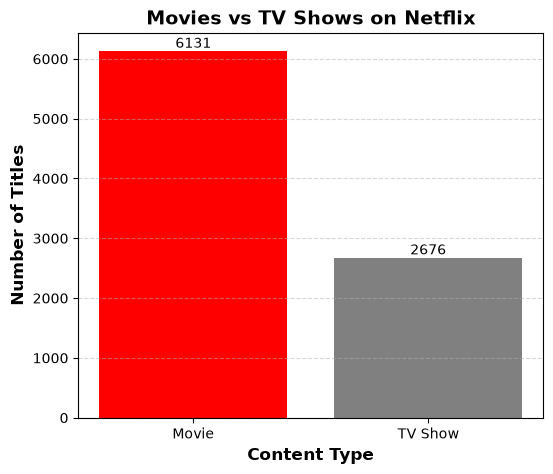

In [ ]:
import matplotlib.pyplot as plt

content_type = netflix["type"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(content_type.index, content_type.values, color=["red", "gray"])
bars = plt.bar(content_type.index, content_type.values, color=["red", "gray"])

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2, #Moves from the left edge to the center of the bar, /2 Half of the width, bar.get_x() Returns the left edge of the bar
        bar.get_height(),                #Returns the height of the bar So the text is placed at the top
        int(bar.get_height()),          #int() converts it into a whole number,
        ha="center",                   #Horizontal Alignment"center" puts the text in the middle of the bar
        va="bottom"                    #Vertical Alignment bottom of the text touches the top of the bar
    )
plt.title("Movies vs TV Shows on Netflix", fontsize=14, fontweight="bold")
plt.xlabel("Content Type", fontsize=12, fontweight="bold")
plt.ylabel("Number of Titles", fontsize=12, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.5)       #linestyle="--" → Dashed lines
plt.savefig( "graphs/movies&TV.png", dpi=300, bbox_inches="tight" )
plt.show()

Movie vs TV Show Percentage

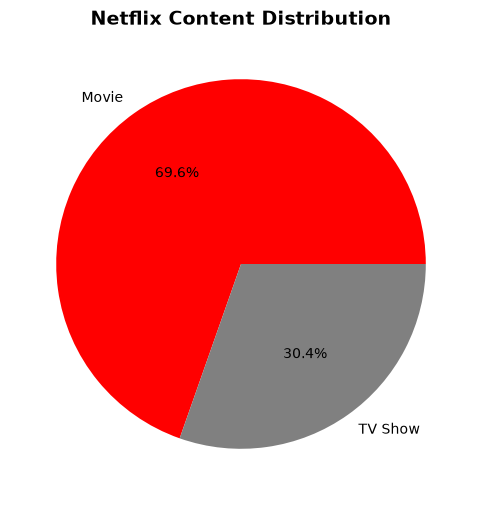

In [ ]:
content_type = netflix["type"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(content_type.values, labels=content_type.index, colors=["red", "gray"], autopct="%1.1f%%") 
plt.title("Netflix Content Distribution", fontsize=14, fontweight="bold")
plt.savefig( "graphs/content.png", dpi=300, bbox_inches="tight" )
plt.show()

Top 10 Directors

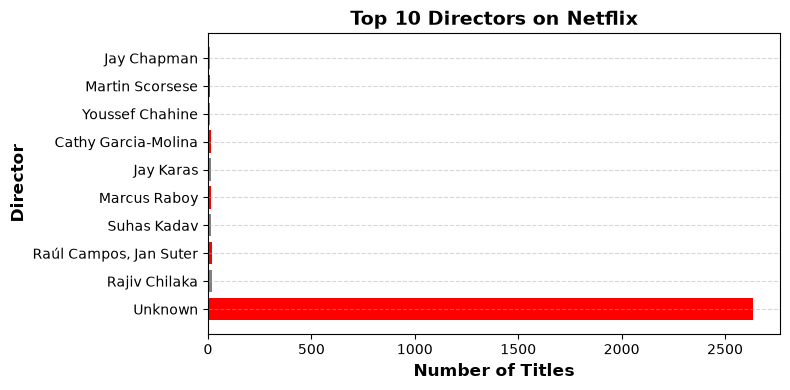

In [ ]:
directors = netflix["director"].value_counts().head(10)

plt.figure(figsize=(8,4))
plt.barh(directors.index, directors.values, color=["red", "gray"])
plt.title("Top 10 Directors on Netflix", fontsize=14, fontweight="bold")
plt.xlabel("Number of Titles", fontsize=12, fontweight="bold")
plt.ylabel("Director", fontsize=12, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig( "graphs/directors.png", dpi=300, bbox_inches="tight" )
plt.show()

Top 10 Release Years

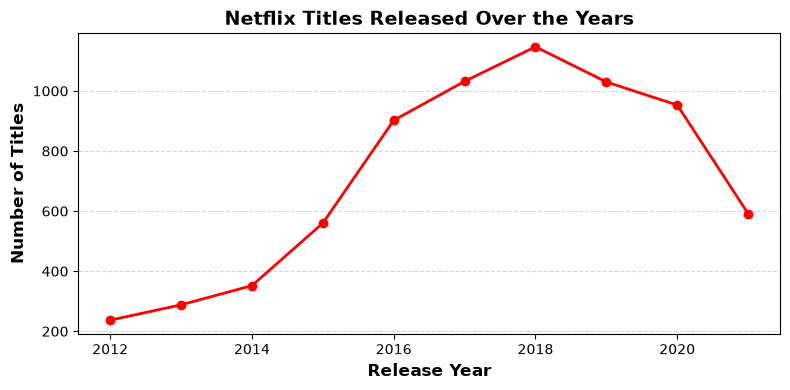

In [ ]:
years = netflix["release_year"].value_counts().sort_index().tail(10)

plt.figure(figsize=(8,4))
plt.plot(years.index, years.values, color="red", marker="o", linewidth=2)
plt.title("Netflix Titles Released Over the Years", fontsize=14, fontweight="bold")
plt.xlabel("Release Year", fontsize=12, fontweight="bold")
plt.ylabel("Number of Titles", fontsize=12, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig( "graphs/Releaseyears.png", dpi=300, bbox_inches="tight" )
plt.show()

Distribution of Release Years

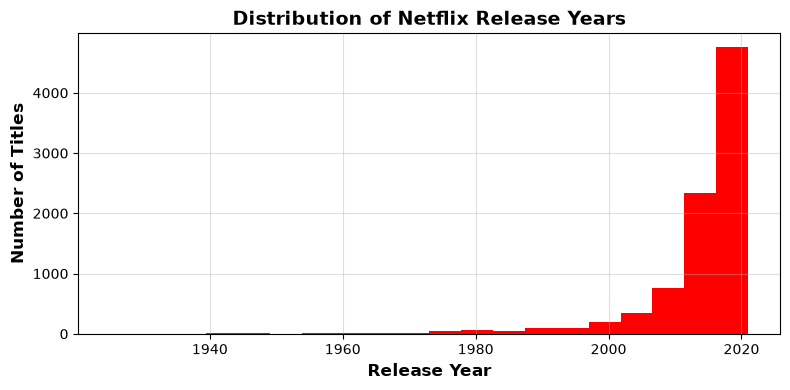

In [ ]:
plt.figure(figsize=(8,4))

plt.hist(netflix["release_year"], color="red", bins=20)    #20 means divide the years into 20 groups (bars).
plt.title("Distribution of Netflix Release Years", fontsize=14, fontweight="bold")
plt.xlabel("Release Year", fontsize=12, fontweight="bold")
plt.ylabel("Number of Titles", fontsize=12, fontweight="bold")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig( "graphs/distributions.png", dpi=300, bbox_inches="tight" )
plt.show()

Top 10 actors 

cast
Unknown             825
Anupam Kher          43
Shah Rukh Khan       35
Julie Tejwani        33
Naseeruddin Shah     32
Takahiro Sakurai     32
Rupa Bhimani         31
Akshay Kumar         30
Om Puri              30
Yuki Kaji            29
Name: count, dtype: int64


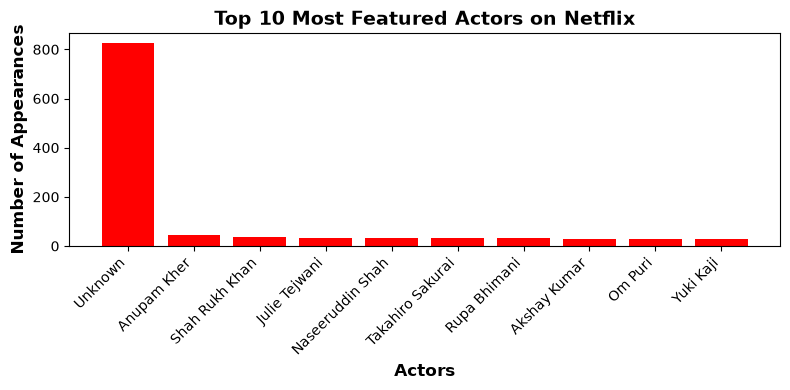

In [ ]:
top_actors = (
    netflix["cast"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)
print(top_actors)

#graph
plt.figure(figsize=(8,4))
plt.bar(top_actors.index, top_actors.values, color="red")
plt.title("Top 10 Most Featured Actors on Netflix", fontsize=14, fontweight="bold")
plt.xlabel("Actors", fontsize=12, fontweight="bold")
plt.ylabel("Number of Appearances", fontsize=12,fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig( "graphs/actors.png", dpi=300, bbox_inches="tight" )
plt.show()